In [23]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
!ls -la /content/drive/MyDrive/Riesgos

total 2585
-rw------- 1 root root    1195 Mar 19 06:30 label_encoders.joblib
-rw------- 1 root root    2103 Mar 19 06:30 minmax_scaler.joblib
-rw------- 1 root root   78456 Mar 19 06:31 modelo_credito.keras
-rw------- 1 root root    2583 Mar 19 06:30 pca_8_componentes.joblib
-rw------- 1 root root 2560393 Mar 12 19:39 riesgo.xlsx


In [25]:
%cd /content/drive/MyDrive/Riesgos

/content/drive/MyDrive/Riesgos


In [26]:
import pandas as pd

df = pd.read_excel("riesgo.xlsx")
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [27]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [28]:
df.drop(columns=["Customer_ID", "Name", "SSN", "Type_of_Loan"], axis=1, inplace=True)
df=df.dropna()
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [29]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.00000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,33.311294,50505.123449,4198.468568,5.368828,5.53362,14.532080,3.532880,21.068780,13.338642,10.465068,5.779694,1426.220376,45.350133,18.433820,54.703501,195.751837,403.120320,0.845200
std,10.760177,38300.762656,3187.142979,2.592493,2.06604,8.741636,2.446442,14.772965,6.153148,6.445141,3.707936,1155.169458,23.142509,8.304817,23.745752,136.847120,175.476887,0.697994
min,14.000000,7005.930000,303.645417,0.000000,0.50000,1.000000,0.000000,-2.000000,0.000000,0.500000,0.000000,0.230000,3.157080,0.375000,2.046130,14.528879,92.841401,0.000000
25%,24.415179,19342.972500,1625.744479,3.000000,4.00000,7.000000,2.000000,9.875000,9.000000,5.493750,3.000000,566.072500,23.269630,12.041667,39.606041,97.690749,284.546710,0.000000
50%,33.000000,36999.705000,3097.016667,5.375000,5.00000,13.000000,3.000000,17.875000,13.750000,9.370000,5.250000,1166.155000,45.394818,18.238095,53.506477,152.081485,338.491580,1.000000
75%,41.750000,71683.470000,5961.664375,7.000000,7.00000,20.000000,5.000000,28.000000,18.175000,14.656250,8.500000,1945.962500,59.420909,25.125000,70.892451,257.566585,465.372970,1.000000
max,56.000000,179987.280000,15204.633333,10.500000,10.87500,34.000000,9.000000,63.250000,26.375000,31.115000,16.375000,4998.070000,125.239110,33.380952,130.333410,1005.847285,1349.264887,2.000000


In [30]:
df.describe(include="object").T

,count,unique,top,freq
Occupation,12500,15,Lawyer,887
Credit_Mix,12500,3,Standard,5731
Payment_of_Min_Amount,12500,3,Yes,7360
Payment_Behaviour,12500,6,Low_spent_Small_value_payments,3860


In [31]:
df.drop(columns=["Occupation"], axis=1, inplace=True)

In [32]:
df = df.reset_index(drop=True)
df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [33]:
object_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(exclude="object").columns.tolist()

print("Columnas object:", object_cols)
print("Columnas numéricas:", numeric_cols)

Columnas object: ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Columnas numéricas: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score']


In [34]:
for col in object_cols:
    print(col, df[col].nunique())

Credit_Mix 3
Payment_of_Min_Amount 3
Payment_Behaviour 6


In [35]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for c in object_cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))
    label_encoders[c] = le

df_limpio = df_encoded[numeric_cols + object_cols].copy()
df_limpio.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,...,1562.91,25.036185,10.458333,81.797271,158.549735,335.375341,0,0,2,1
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,...,202.68,50.771467,30.714286,53.546010,146.679378,428.743155,1,2,2,1
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,...,1030.20,29.610420,15.571429,83.438236,505.386526,781.229776,0,1,1,0
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,...,473.14,43.950325,15.541667,56.104813,311.060914,332.642837,1,2,2,4
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,...,1233.51,44.397384,17.535714,50.146076,355.442408,472.781009,1,1,1,1


In [36]:
import joblib

joblib.dump(label_encoders, "label_encoders.joblib")

print("Label encoders guardados en 'label_encoders.joblib'")

Label encoders guardados en 'label_encoders.joblib'


In [37]:
from sklearn.feature_selection import SelectKBest, f_classif

y = df_limpio["Credit_Score"]
X = df_limpio.drop(columns=["Credit_Score"])

selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
selected_features.tolist()

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Total_EMI_per_month',
 'Monthly_Balance',
 'Credit_Mix',
 'Payment_of_Min_Amount']

In [38]:
columnas_es = {
    "Age": "Edad",
    "Annual_Income": "Ingreso_Anual",
    "Monthly_Inhand_Salary": "Salario_Mensual_Disponible",
    "Num_Bank_Accounts": "Num_Cuentas_Bancarias",
    "Num_Credit_Card": "Num_Tarjetas_Credito",
    "Interest_Rate": "Tasa_Interes",
    "Num_of_Loan": "Num_Prestamos",
    "Delay_from_due_date": "Retraso_Desde_Fecha_Vencimiento",
    "Num_of_Delayed_Payment": "Num_Pagos_Atrasados",
    "Changed_Credit_Limit": "Cambio_Limite_Credito",
    "Num_Credit_Inquiries": "Num_Consultas_Credito",
    "Credit_Mix": "Mezcla_Credito",
    "Outstanding_Debt": "Deuda_Pendiente",
    "Credit_Utilization_Ratio": "Ratio_Uso_Credito",
    "Credit_History_Age": "Antiguedad_Historial_Credito",
    "Payment_of_Min_Amount": "Pago_Monto_Minimo",
    "Total_EMI_per_month": "EMI_Total_Mensual",
    "Amount_invested_monthly": "Monto_Invertido_Mensual",
    "Payment_Behaviour": "Comportamiento_Pago",
    "Monthly_Balance": "Balance_Mensual",
    "Credit_Score": "Puntaje_Credito",
}

df.rename(columns=columnas_es, inplace=True)
df.head()

,Edad,Ingreso_Anual,Salario_Mensual_Disponible,Num_Cuentas_Bancarias,Num_Tarjetas_Credito,Tasa_Interes,Num_Prestamos,Retraso_Desde_Fecha_Vencimiento,Num_Pagos_Atrasados,Cambio_Limite_Credito,...,Mezcla_Credito,Deuda_Pendiente,Ratio_Uso_Credito,Antiguedad_Historial_Credito,Pago_Monto_Minimo,EMI_Total_Mensual,Monto_Invertido_Mensual,Comportamiento_Pago,Balance_Mensual,Puntaje_Credito
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "minmax_scaler.joblib")
print("Scaler guardado en 'minmax_scaler.joblib'")

Scaler guardado en 'minmax_scaler.joblib'


In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)

joblib.dump(pca, "pca_8_componentes.joblib")
print("PCA guardado en 'pca_8_componentes.joblib'")

componentes = [f"PC{i+1}" for i in range(pca.n_components_)]
pesos = pd.DataFrame(pca.components_.T, index=X.columns, columns=componentes)
pesos

PCA guardado en 'pca_8_componentes.joblib'


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Age,0.110513,0.031731,-0.134301,-0.290289,0.902778,0.226694,-0.113281,0.004948
Annual_Income,0.168287,-0.314748,0.021309,0.487741,0.139709,0.050140,0.010079,0.052371
Monthly_Inhand_Salary,0.162365,-0.304898,0.021177,0.470721,0.134611,0.047185,0.008782,0.051488
Num_Bank_Accounts,-0.252940,-0.038056,0.171343,0.004059,0.149636,-0.113962,0.518317,0.201110
Num_Credit_Card,-0.178207,-0.063284,0.024433,0.003820,0.092109,-0.179929,0.002924,-0.145025
Interest_Rate,-0.307662,-0.070939,0.146029,0.031318,0.119578,-0.112437,0.023188,-0.110757
Num_of_Loan,-0.302928,-0.110098,-0.005300,0.009455,-0.060772,0.319363,-0.294787,0.737443
Delay_from_due_date,-0.242350,-0.088535,0.025974,0.012085,0.126738,-0.183130,0.203685,-0.025562
Num_of_Delayed_Payment,-0.240085,-0.038739,0.144170,-0.010025,0.122786,-0.064291,0.431996,0.156818
Changed_Credit_Limit,-0.151617,-0.023117,0.167403,0.043118,-0.030645,0.474041,-0.020351,-0.502524


In [41]:
y_original = y.copy()
y_one_hot = pd.get_dummies(y_original, prefix="Credit_Score")

print("y original:")
display(y_original.head())

print("y one-hot:")
display(y_one_hot.head())

y original:


,Credit_Score
0,0
1,1
2,0
3,1
4,1


y one-hot:


,Credit_Score_0,Credit_Score_1,Credit_Score_2
0,True,False,False
1,False,True,False
2,True,False,False
3,False,True,False
4,False,True,False


In [42]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_one_hot,
    test_size=0.15,
    random_state=42,
    stratify=y_one_hot,
)

# Usar el set de entrenamiento en el fit de abajo
X_scaled = X_train
y_one_hot = y_train

model = Sequential([
    Input(shape=(X_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X_scaled, y_one_hot, epochs=50, batch_size=32, validation_split=0.15, verbose=1)

Epoch 1/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8626 - loss: 0.3791 - val_accuracy: 0.9831 - val_loss: 0.0793
Epoch 2/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0648 - val_accuracy: 0.9818 - val_loss: 0.0519
Epoch 3/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0526 - val_accuracy: 0.9743 - val_loss: 0.0621
Epoch 4/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9804 - loss: 0.0482 - val_accuracy: 0.9624 - val_loss: 0.0982
Epoch 5/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9818 - loss: 0.0457 - val_accuracy: 0.9793 - val_loss: 0.0523
Epoch 6/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9845 - loss: 0.0415 - val_accuracy: 0.9875 - val_loss: 0.0374
Epoch 7/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9832 - loss: 0.0409 - val_accuracy: 0.9868 - val_loss: 0.0383
Epoch 8/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9864 - loss: 0.0354 - val_accuracy: 0.

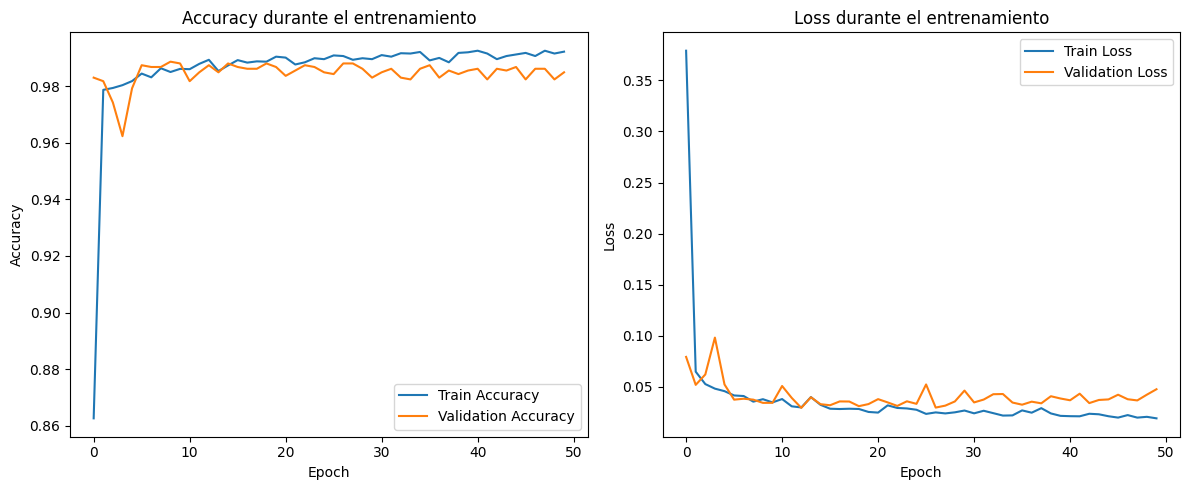

In [43]:
pd.DataFrame(history.history)
#crear la grafica del history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [44]:
model.save("modelo_credito.keras")
print("Modelo guardado en 'modelo_credito.keras'")

Modelo guardado en 'modelo_credito.keras'


In [45]:
import os
import shutil
import zipfile
from pathlib import Path
from google.colab import files

# Artefactos generados en el entrenamiento
artefactos = [
    "modelo_credito.keras",
    "minmax_scaler.joblib",
    "label_encoders.joblib",
    "pca_8_componentes.joblib",
]

# Copia a Google Drive
destino_drive = "/content/drive/MyDrive/Riesgos/modelo_taller2"
os.makedirs(destino_drive, exist_ok=True)

faltantes = []
for nombre in artefactos:
    origen = Path(nombre)
    if origen.exists():
        shutil.copy2(origen, Path(destino_drive) / nombre)
    else:
        faltantes.append(nombre)

print(f"Artefactos copiados en: {destino_drive}")
if faltantes:
    print("Faltantes:", faltantes)
else:
    print("Todos los artefactos fueron encontrados y copiados.")

# Crea ZIP para descarga directa
zip_name = "artefactos_taller2.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for nombre in artefactos:
        archivo = Path(nombre)
        if archivo.exists():
            zf.write(archivo, arcname=nombre)

print(f"ZIP generado: {zip_name}")
files.download(zip_name)

Artefactos copiados en: /content/drive/MyDrive/Riesgos/modelo_taller2
Todos los artefactos fueron encontrados y copiados.
ZIP generado: artefactos_taller2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>